# CS-4063 <br> Natural Language Processing - Assignment 3

**Muhammad Moiz Khalid** <br>
**23i-2552**<br>
**BDS-6C**

### Github Link: https://github.com/moizkhalidd/i23-2552-NLP-Assignment3

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, re, json, math, pickle, random, torch
import numpy as np, matplotlib.pyplot as plt
import torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report
from collections import Counter
#Setup
random.seed(42); np.random.seed(42); torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
[os.makedirs(d, exist_ok=True) for d in ['models', 'results']]

Device: cuda


[None, None]

In [3]:
import gzip
import shutil
import os

drive_path = "/content/drive/MyDrive"

gz_files = [
    "cellphones.json.gz",
    "beauty.json.gz",
    "home.json.gz"
]

for gz_file in gz_files:
    gz_path = os.path.join(drive_path, gz_file)

    with gzip.open(gz_path, 'rb') as f_in:
        original_name = f_in.name.split("/")[-1].replace(".gz", "")

        output_path = os.path.join("/content", original_name)

        with open(output_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

    print(f"Extracted to: {output_path}")

Extracted to: /content/cellphones.json
Extracted to: /content/beauty.json
Extracted to: /content/home.json


## Dataset Loading and Preprocessing

In [4]:
def loadCategoryData(filePath, maxSamples):
    records = []
    with open(filePath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
                text = obj.get('reviewText', '').strip()
                rating = float(obj.get('overall', 0))
                if text and 1 <= rating <= 5:
                    records.append({'text': text, 'rating': rating})
            except (json.JSONDecodeError, ValueError):
                continue
            if len(records) >= maxSamples:
                break
    return records

In [5]:
allRecords = []

# ~36 000 total — within 30k–45k range
catRecords = loadCategoryData('cellphones.json', 12000)
allRecords.extend(catRecords)
print('Loaded {:>6} records from {}'.format(len(catRecords), 'cellphones.json'))

catRecords = loadCategoryData('beauty.json', 12000)
allRecords.extend(catRecords)
print('Loaded {:>6} records from {}'.format(len(catRecords), 'beauty.json'))

catRecords = loadCategoryData('home.json', 12000)
allRecords.extend(catRecords)
print('Loaded {:>6} records from {}'.format(len(catRecords), 'home.json'))

print()
print('Total records loaded: {}'.format(len(allRecords)))

Loaded  12000 records from cellphones.json
Loaded  12000 records from beauty.json
Loaded  12000 records from home.json

Total records loaded: 36000


In [6]:
#preprocessing
def cleanText(text):
    text = text.lower()
     # strip HTML
    text = re.sub(r'<[^>]+>', ' ', text)
    # keep alnum + apostrophe/hyphen
    text = re.sub(r'[^a-z0-9\s\'\-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def simpleTokenize(text):
    #tokenization after cleaning
    return cleanText(text).split()


for rec in allRecords:
    rec['tokens'] = simpleTokenize(rec['text'])

print('Sample tokens (first record):', allRecords[0]['tokens'][:15])

Sample tokens (first record): ['they', 'look', 'good', 'and', 'stick', 'good', 'i', 'just', "don't", 'like', 'the', 'rounded', 'shape', 'because', 'i']


In [7]:
#split
random.shuffle(allRecords)

n = len(allRecords)
nTrain = int(n * 0.70)
nVal = int(n * 0.15)

trainData = allRecords[:nTrain]
valData = allRecords[nTrain : nTrain + nVal]
testData = allRecords[nTrain + nVal:]

print('Train size : {}'.format(len(trainData)))
print('Val size : {}'.format(len(valData)))
print('Test size : {}'.format(len(testData)))

Train size : 25200
Val size : 5400
Test size : 5400


In [8]:
#Vocabulary
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'
BOS_TOKEN = '<BOS>'
EOS_TOKEN = '<EOS>'
SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN]

wordFreq = Counter()
for rec in trainData:
    wordFreq.update(rec['tokens'])

vocabWords = []
for w, c in wordFreq.most_common(30000):
    #min frequency threshold
    if c >= 3:
        vocabWords.append(w)

vocab = SPECIAL_TOKENS + vocabWords

word2idx = {}
for i, w in enumerate(vocab):
    word2idx[w] = i

idx2word = {}
for w, i in word2idx.items():
    idx2word[i] = w

PAD_IDX = word2idx[PAD_TOKEN]
UNK_IDX = word2idx[UNK_TOKEN]
BOS_IDX = word2idx[BOS_TOKEN]
EOS_IDX = word2idx[EOS_TOKEN]

VOCAB_SIZE = len(vocab)
print('Vocabulary size: {}'.format(VOCAB_SIZE))

Vocabulary size: 15895


In [9]:
# label mapping
# sentiment: 1-2 = 0 (Negative), 3 = 1 (Neutral), 4-5 = 2 (Positive)
def ratingToSentiment(rating):
    if rating <= 2:
        return 0
    elif rating == 3:
        return 1
    else:
        return 2

# derived feature: review length bucket
#Short  (< 50 tokens)  = 0
#Medium (50-150 tokens) = 1
#Long   (>150 tokens)  = 2
def lengthBucket(tokens):
    n = len(tokens)
    if n < 50:
        return 0
    elif n <= 150:
        return 1
    else:
        return 2

for rec in allRecords:
    rec['sentiment']   = ratingToSentiment(rec['rating'])
    rec['lengthClass'] = lengthBucket(rec['tokens'])

sentDist = Counter(r['sentiment']   for r in allRecords)
lenDist = Counter(r['lengthClass'] for r in allRecords)
print('Sentiment distribution : {}'.format(dict(sentDist)))
print('Length-class distribution: {}'.format(dict(lenDist)))

Sentiment distribution : {2: 28290, 0: 4390, 1: 3320}
Length-class distribution: {0: 15750, 1: 14252, 2: 5998}


In [10]:
#numericalization helpers
MAX_SEQ_LEN = 128

def encodeTokens(tokens, maxLen=MAX_SEQ_LEN):
    """Convert tokens to padded/truncated index tensor with leading CLS token."""
    # Reserve position 0 for CLS; content fills positions 1..maxLen-1
    ids = []

    #CLS token
    ids.append(UNK_IDX)

    # convert tokens to indices one by one
    for t in tokens[:maxLen - 1]:
        if t in word2idx:
            ids.append(word2idx[t])
        else:
            ids.append(UNK_IDX)

    # padding
    ids = ids + [PAD_IDX] * (maxLen - len(ids))
    return ids


class ReviewDataset(Dataset):
    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        inputIds = torch.tensor(encodeTokens(rec['tokens']), dtype=torch.long)
        sentLabel = torch.tensor(rec['sentiment'],   dtype=torch.long)
        lenLabel = torch.tensor(rec['lengthClass'], dtype=torch.long)
        return inputIds, sentLabel, lenLabel


trainDataset = ReviewDataset(trainData)
valDataset = ReviewDataset(valData)
testDataset = ReviewDataset(testData)

trainLoader = DataLoader(trainDataset, batch_size=64, shuffle=True)
valLoader = DataLoader(valDataset, batch_size=64, shuffle=False)
testLoader = DataLoader(testDataset, batch_size=64, shuffle=False)

print('DataLoaders ready.')

DataLoaders ready.


## Part A) Encoder-Only Transformer Model

In [11]:
# positional encoding
class PositionalEncoding(nn.Module):
    def __init__(self, dModel, maxLen=MAX_SEQ_LEN, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # (maxLen, dModel)
        pe = torch.zeros(maxLen, dModel)
        # (maxLen, 1)
        position = torch.arange(0, maxLen).unsqueeze(1).float()
        divTerm = torch.exp(torch.arange(0, dModel, 2).float() * (-math.log(10000.0) / dModel))
        pe[:, 0::2] = torch.sin(position * divTerm)
        pe[:, 1::2] = torch.cos(position * divTerm)
        pe = pe.unsqueeze(0)
        # (1, maxLen, dModel)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x : (batch, seqLen, dModel)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [12]:
# scaled Dot-Product Attention
class ScaledDotProductAttention(nn.Module):
    def __init__(self, dK, dropout=0.1):
        super(ScaledDotProductAttention, self).__init__()
        self.scale = math.sqrt(dK)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, queries, keys, values, mask=None):
        # queries/keys/values: (batch, heads, seqLen, dK)
        scores = torch.matmul(queries, keys.transpose(-2, -1)) / self.scale
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attnWeights = torch.softmax(scores, dim=-1)
        attnWeights = self.dropout(attnWeights)
        output      = torch.matmul(attnWeights, values)
        return output, attnWeights

In [13]:
# multi-Head Attention
class MultiHeadAttention(nn.Module):
    def __init__(self, dModel, nHeads, dropout=0.1):
        super(MultiHeadAttention, self).__init__()
        assert dModel % nHeads == 0
        self.nHeads = nHeads
        self.dModel = dModel
        self.dK = dModel // nHeads

        #separate linear projections for Q, K, V for each head
        self.wQ = nn.Linear(dModel, dModel, bias=False)
        self.wK = nn.Linear(dModel, dModel, bias=False)
        self.wV = nn.Linear(dModel, dModel, bias=False)
        self.wO = nn.Linear(dModel, dModel)

        self.attention = ScaledDotProductAttention(self.dK, dropout)
        self.dropout = nn.Dropout(p=dropout)

    def splitHeads(self, x):
        # x: (batch, seqLen, dModel) to (batch, nHeads, seqLen, dK)
        batch, seqLen, _ = x.size()
        x = x.view(batch, seqLen, self.nHeads, self.dK)
        return x.transpose(1, 2)

    def forward(self, queries, keys, values, mask=None):
        batch = queries.size(0)

        q = self.splitHeads(self.wQ(queries))
        k = self.splitHeads(self.wK(keys))
        v = self.splitHeads(self.wV(values))

        attnOut, _ = self.attention(q, k, v, mask)

        # Concatenate heads
        attnOut = attnOut.transpose(1, 2).contiguous().view(batch, -1, self.dModel)
        output = self.wO(attnOut)
        return output

In [14]:
#position-wise Feed-Forward Network
class FeedForward(nn.Module):
    def __init__(self, dModel, dFF, dropout=0.1):
        super(FeedForward, self).__init__()
        self.linear1 = nn.Linear(dModel, dFF)
        self.linear2 = nn.Linear(dFF, dModel)
        self.dropout = nn.Dropout(p=dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.linear2(self.dropout(self.relu(self.linear1(x))))

In [15]:
# encoder block
class EncoderBlock(nn.Module):
    def __init__(self, dModel, nHeads, dFF, dropout=0.1):
        super(EncoderBlock, self).__init__()
        self.selfAttn = MultiHeadAttention(dModel, nHeads, dropout)
        self.ffn = FeedForward(dModel, dFF, dropout)
        self.norm1 = nn.LayerNorm(dModel)
        self.norm2 = nn.LayerNorm(dModel)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, srcMask=None):
        #Multi-head self-attention + residual + norm
        attnOut = self.selfAttn(x, x, x, srcMask)
        x = self.norm1(x + self.dropout(attnOut))
        # Feed-forward + residual + norm
        ffnOut = self.ffn(x)
        x = self.norm2(x + self.dropout(ffnOut))
        return x

In [16]:
#full Encoder Model with Multi-Task Heads
class EncoderTransformer(nn.Module):
    def __init__(self, vocabSize, dModel, nHeads, nLayers, dFF,maxLen=MAX_SEQ_LEN, dropout=0.1, numSentClasses=3, numLenClasses=3):
        super(EncoderTransformer, self).__init__()

        self.embedding = nn.Embedding(vocabSize, dModel, padding_idx=PAD_IDX)
        self.posEnc = PositionalEncoding(dModel, maxLen, dropout)
        self.layers = nn.ModuleList([EncoderBlock(dModel, nHeads, dFF, dropout) for _ in range(nLayers)])
        self.norm = nn.LayerNorm(dModel)

        # Multi-task classification heads
        self.sentHead = nn.Linear(dModel, numSentClasses)
        self.lenHead = nn.Linear(dModel, numLenClasses)

    def makePaddingMask(self, src):
        # src: (batch, seqLen); mask shape: (batch, 1, 1, seqLen)
        mask = (src != PAD_IDX).unsqueeze(1).unsqueeze(2)
        return mask

    def encode(self, src):
        """per-token encoder outputs and CLS embedding."""
        mask = self.makePaddingMask(src)
          # (batch, seqLen, dModel)
        x = self.posEnc(self.embedding(src))
        for layer in self.layers:
            x = layer(x, mask)
        x = self.norm(x)
         # (batch, dModel)
        clsEmb = x[:, 0, :]
        return x, clsEmb

    def forward(self, src):
        x, clsEmb = self.encode(src)
        sentLogits = self.sentHead(clsEmb)         # (batch, 3)
        lenLogits = self.lenHead(clsEmb)          # (batch, 3)
        return sentLogits, lenLogits, clsEmb

In [17]:
# hyperparameters
D_MODEL = 128
N_HEADS = 4
N_LAYERS = 2
D_FF = 256
DROPOUT = 0.1
LR = 1e-3
ENC_EPOCHS = 10

encoderModel = EncoderTransformer(vocabSize=VOCAB_SIZE,dModel=D_MODEL,nHeads=N_HEADS,nLayers=N_LAYERS,dFF=D_FF,dropout=DROPOUT).to(DEVICE)

print('Encoder parameters: {:,}'.format(sum(p.numel() for p in encoderModel.parameters() if p.requires_grad)))

Encoder parameters: 2,299,782


In [18]:
# training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(encoderModel.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.5)

trainLosses = []
valLosses = []

for epoch in range(ENC_EPOCHS):
    encoderModel.train()
    epochLoss = 0.0
    for inputIds, sentLabels, lenLabels in trainLoader:
        inputIds = inputIds.to(DEVICE)
        sentLabels = sentLabels.to(DEVICE)
        lenLabels = lenLabels.to(DEVICE)

        optimizer.zero_grad()
        sentLogits, lenLogits, _ = encoderModel(inputIds)

        lossSent = criterion(sentLogits, sentLabels)
        lossLen = criterion(lenLogits,  lenLabels)
        loss = lossSent + lossLen

        loss.backward()
        nn.utils.clip_grad_norm_(encoderModel.parameters(), max_norm=1.0)
        optimizer.step()
        epochLoss += loss.item()

    avgTrainLoss = epochLoss / len(trainLoader)
    trainLosses.append(avgTrainLoss)

    # validation
    encoderModel.eval()
    epochValLoss = 0.0
    with torch.no_grad():
        for inputIds, sentLabels, lenLabels in valLoader:
            inputIds   = inputIds.to(DEVICE)
            sentLabels = sentLabels.to(DEVICE)
            lenLabels  = lenLabels.to(DEVICE)
            sentLogits, lenLogits, _ = encoderModel(inputIds)
            lVal = criterion(sentLogits, sentLabels) + criterion(lenLogits, lenLabels)
            epochValLoss += lVal.item()

    avgValLoss = epochValLoss / len(valLoader)
    valLosses.append(avgValLoss)
    scheduler.step()

    print('Epoch [{}/{}]  Train Loss: {:.4f}  Val Loss: {:.4f}'.format(
        epoch + 1, ENC_EPOCHS, avgTrainLoss, avgValLoss))

Epoch [1/10]  Train Loss: 0.8108  Val Loss: 0.7413
Epoch [2/10]  Train Loss: 0.6724  Val Loss: 0.6626
Epoch [3/10]  Train Loss: 0.6191  Val Loss: 0.6687
Epoch [4/10]  Train Loss: 0.5866  Val Loss: 0.6468
Epoch [5/10]  Train Loss: 0.5695  Val Loss: 0.6424
Epoch [6/10]  Train Loss: 0.5637  Val Loss: 0.6313
Epoch [7/10]  Train Loss: 0.5547  Val Loss: 0.6332
Epoch [8/10]  Train Loss: 0.5542  Val Loss: 0.6358
Epoch [9/10]  Train Loss: 0.5538  Val Loss: 0.6339
Epoch [10/10]  Train Loss: 0.5552  Val Loss: 0.6329


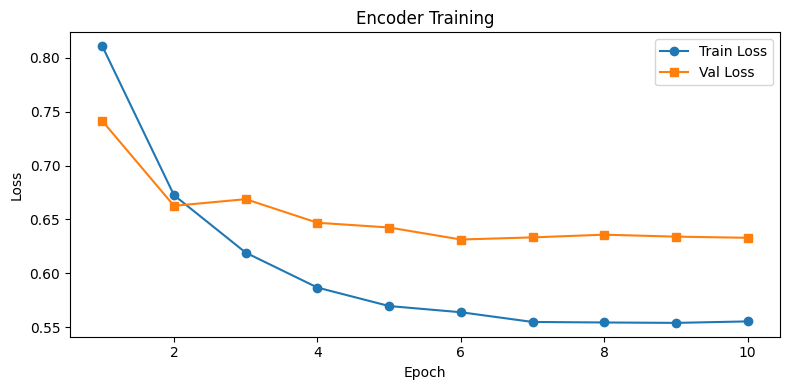

Learning curve saved.


In [19]:
# curves
plt.figure(figsize=(8, 4))
plt.plot(range(1, ENC_EPOCHS + 1), trainLosses, marker='o', label='Train Loss')
plt.plot(range(1, ENC_EPOCHS + 1), valLosses,   marker='s', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Encoder Training')
plt.legend()
plt.tight_layout()
plt.savefig('results/encoderLearning.png')
plt.show()
print('Learning curve saved.')

In [20]:
# evaluation
encoderModel.eval()

allSentPreds, allSentTrue = [], []
allLenPreds, allLenTrue  = [], []

with torch.no_grad():
    for inputIds, sentLabels, lenLabels in testLoader:
        inputIds = inputIds.to(DEVICE)
        sentLogits, lenLogits, _ = encoderModel(inputIds)

        sentPreds = sentLogits.argmax(dim=-1).cpu().tolist()
        lenPreds = lenLogits.argmax(dim=-1).cpu().tolist()

        allSentPreds.extend(sentPreds)
        allSentTrue.extend(sentLabels.tolist())
        allLenPreds.extend(lenPreds)
        allLenTrue.extend(lenLabels.tolist())

print('Sentiment Classification')
print(classification_report(allSentTrue, allSentPreds,target_names=['Negative', 'Neutral', 'Positive']))
print()
print('Review Length Classification')
print(classification_report(allLenTrue, allLenPreds,target_names=['Short', 'Medium', 'Long']))

Sentiment Classification
              precision    recall  f1-score   support

    Negative       0.57      0.47      0.52       634
     Neutral       0.25      0.03      0.05       525
    Positive       0.85      0.96      0.90      4241

    accuracy                           0.81      5400
   macro avg       0.56      0.49      0.49      5400
weighted avg       0.76      0.81      0.77      5400


Review Length Classification
              precision    recall  f1-score   support

       Short       1.00      1.00      1.00      2370
      Medium       0.99      0.88      0.93      2127
        Long       0.77      0.99      0.87       903

    accuracy                           0.95      5400
   macro avg       0.92      0.95      0.93      5400
weighted avg       0.96      0.95      0.95      5400



In [21]:
# encoder weights
torch.save(encoderModel.state_dict(), 'models/encoder.pt')
print('Encoder weights saved to models/encoder.pt')

Encoder weights saved to models/encoder.pt


In [22]:
#training-set embeddings
encoderModel.eval()

trainEmbeddings = []
trainSentLabels = []
trainLenLabels  = []

with torch.no_grad():
    for inputIds, sentLabels, lenLabels in trainLoader:
        inputIds = inputIds.to(DEVICE)
        _, _, clsEmb = encoderModel(inputIds)
        trainEmbeddings.append(clsEmb.cpu().numpy())
        trainSentLabels.extend(sentLabels.tolist())
        trainLenLabels.extend(lenLabels.tolist())

trainEmbeddings = np.concatenate(trainEmbeddings, axis=0)

embStore = {'embeddings': trainEmbeddings,'sentLabels': trainSentLabels,'lenLabels': trainLenLabels,'texts': [r['text'] for r in trainData]}

with open('results/train_embeddings.pkl', 'wb') as f:
    pickle.dump(embStore, f)

print('Training embeddings saved: shape = {}'.format(trainEmbeddings.shape))

Training embeddings saved: shape = (25200, 128)


## Part B) Retrieval Module

In [23]:
# stored embeddings
with open('results/train_embeddings.pkl', 'rb') as f:
    embStore = pickle.load(f)

trainEmbs = embStore['embeddings']
trainTexts = embStore['texts']
trainSents = embStore['sentLabels']

# L2-normalise for cosine similarity via dot product
def l2Normalize(matrix):
    norms = np.linalg.norm(matrix, axis=1, keepdims=True) + 1e-9
    return matrix / norms

trainEmbsNorm = l2Normalize(trainEmbs)
print('Loaded {} training embeddings of dim {}'.format(trainEmbsNorm.shape[0], trainEmbsNorm.shape[1]))

Loaded 25200 training embeddings of dim 128


In [24]:
# query construction and similarity search
TOP_K = 3

def buildQueryEmbedding(text):
    """Encode a single review text and return its L2-normalised embedding."""
    tokens  = simpleTokenize(text)
    ids     = torch.tensor([encodeTokens(tokens)], dtype=torch.long).to(DEVICE)
    encoderModel.eval()
    with torch.no_grad():
        _, _, clsEmb = encoderModel(ids)
    emb = clsEmb.cpu().numpy()
    return l2Normalize(emb)


def retrieveTopK(queryEmb, k=TOP_K):
    """
    Cosine similarity search over training embeddings.
    """
    scores = trainEmbsNorm.dot(queryEmb.T).flatten()
    topIdxs = np.argsort(scores)[::-1][:k]
    return topIdxs, scores[topIdxs]


print('Retrieval module ready. k = {}'.format(TOP_K))

Retrieval module ready. k = 3


In [25]:
#analysis
sentMap = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

print('Retrieval Quality Analysis')

for qi in range(5):
    queryRec = testData[qi]
    queryEmb = buildQueryEmbedding(queryRec['text'])
    topIdxs, topScores = retrieveTopK(queryEmb, k=TOP_K)

    print()
    print('Query #{}: [{}] {:.50s}...'.format(qi + 1, sentMap[queryRec['sentiment']], queryRec['text']))
    print('Retrieved results:')
    for rank, (idx, score) in enumerate(zip(topIdxs, topScores), 1):
        print('{}. (cos={:.4f}) [{}] {:.60s}...'.format(rank, score, sentMap[trainSents[idx]], trainTexts[idx]))

print()

Retrieval Quality Analysis

Query #1: [Positive] This tool repair kit is useful for repairs on a la...
Retrieved results:
1. (cos=0.9952) [Positive] worked great, no problems for me. it has a very durable buil...
2. (cos=0.9950) [Positive] I have been using the YouCurl wand (Conair) for over a year,...
3. (cos=0.9940) [Positive] I was looking for a no frills car speaker to use with my Bla...

Query #2: [Positive] I had to replace the cord from the first one I pur...
Retrieved results:
1. (cos=0.9914) [Positive] I bought my Nokia 5800 XM from Amazon & used the free shippi...
2. (cos=0.9907) [Neutral] This wasn't exactly a miracle product for me, but it's a gre...
3. (cos=0.9905) [Negative] it didnt seem to work, my pore look the same as always, and ...

Query #3: [Negative] You will have to use more then regular shampoo, be...
Retrieved results:
1. (cos=0.9904) [Negative] I'm on long flights often, and a few years ago I got a Bose ...
2. (cos=0.9871) [Positive] This is a great size, It 

In [26]:
#effect of k
print('Effect of k on retrieved sentiment distribution:')
print()
queryEmb = buildQueryEmbedding(testData[0]['text'])
for k in [1, 3, 5, 10]:
    idxs, scores = retrieveTopK(queryEmb, k=k)
    sentCounts = Counter(sentMap[trainSents[i]] for i in idxs)
    avgScore = scores.mean()
    print(' k={:>2}  avg_cos={:.4f}  sentiment_dist={}'.format(k, avgScore, dict(sentCounts)))

Effect of k on retrieved sentiment distribution:

 k= 1  avg_cos=0.9952  sentiment_dist={'Positive': 1}
 k= 3  avg_cos=0.9948  sentiment_dist={'Positive': 3}
 k= 5  avg_cos=0.9944  sentiment_dist={'Positive': 5}
 k=10  avg_cos=0.9939  sentiment_dist={'Positive': 10}


## Part C) Decoder-Only Transformer

In [27]:
SEG_TOKENS = ['[REVIEW]', '[SENT]', '[LEN]', '[CTX]', '[EXP]']

for tok in SEG_TOKENS:
    if tok not in word2idx:
        idx = len(vocab)
        vocab.append(tok)
        word2idx[tok] = idx
        idx2word[idx] = tok

VOCAB_SIZE = len(vocab)
SENT_WORDS = {0: 'negative', 1: 'neutral', 2: 'positive'}
LEN_WORDS  = {0: 'short', 1: 'medium', 2:'long'}

print('Updated vocabulary size: {}'.format(VOCAB_SIZE))

Updated vocabulary size: 15900


In [28]:
def buildReferenceExplanation(sentLabel, lenLabel, topTokens):
    sentWord = SENT_WORDS[sentLabel]
    lenWord  = LEN_WORDS[lenLabel]
    keyWords = [t for t in topTokens[:5] if len(t) > 3]
    keyStr   = ' '.join(keyWords) if keyWords else 'the product'
    return 'this {} review indicates {} sentiment about {}'.format(lenWord, sentWord, keyStr)


# pre-compute reference explanations for all splits
def addExplanations(records):
    for rec in records:
        rec['explanation'] = buildReferenceExplanation(
            rec['sentiment'], rec['lengthClass'], rec['tokens']
        )

addExplanations(trainData)
addExplanations(valData)
addExplanations(testData)
print('Reference explanations generated. Example:')
print(trainData[0]['explanation'])

Reference explanations generated. Example:
this short review indicates positive sentiment about these


In [29]:
#decoder input construction
# max tokens for combined decoder input
DEC_MAX_LEN = 192
# max tokens for explanation portion
EXP_MAX_LEN = 32

def buildDecoderInput(rec, retrievedTexts, includeRetrieval=True):
    """
    Build the combined input sequence for the decoder.
    """
    def enc(word):
        return word2idx.get(word, UNK_IDX)

    ids = []
    # [REVIEW] + review tokens
    ids += [enc('[REVIEW]')] + [enc(t) for t in rec['tokens'][:80]]
    # [SENT] + sentiment word
    ids += [enc('[SENT]'), enc(SENT_WORDS[rec['sentiment']])]
    # [LEN] + length word
    ids += [enc('[LEN]'), enc(LEN_WORDS[rec['lengthClass']])]
    # [CTX] + each retrieved review (truncated to 20 tokens each)
    if includeRetrieval:
        for ctxText in retrievedTexts:
            ctxToks = simpleTokenize(ctxText)[:20]
            ids += [enc('[CTX]')] + [enc(t) for t in ctxToks]
    # [EXP] <BOS> + explanation tokens
    expToks = simpleTokenize(rec['explanation'])[:EXP_MAX_LEN]
    ids += [enc('[EXP]'), BOS_IDX] + [enc(t) for t in expToks] + [EOS_IDX]
    # Truncate and pad to DEC_MAX_LEN
    ids = ids[:DEC_MAX_LEN]
    ids = ids + [PAD_IDX] * (DEC_MAX_LEN - len(ids))
    return ids


def getRandomRetrievedTexts(idx, k=TOP_K):
    pool = list(range(len(trainData)))
    pool.remove(idx)
    chosen = random.sample(pool, min(k, len(pool)))
    return [trainData[c]['text'] for c in chosen]

print('Decoder input builder ready.')

Decoder input builder ready.


In [30]:
# Decoder Dataset
class DecoderDataset(Dataset):
    def __init__(self, records, isTrain=False, includeRetrieval=True):
        self.records = records
        self.isTrain = isTrain
        self.includeRetrieval = includeRetrieval

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        if self.isTrain:
            ctxTexts = getRandomRetrievedTexts(idx, TOP_K)
        else:
            qEmb = buildQueryEmbedding(rec['text'])
            topIdxs, _ = retrieveTopK(qEmb, TOP_K)
            ctxTexts = [trainTexts[i] for i in topIdxs]
        inputIds = buildDecoderInput(rec, ctxTexts, self.includeRetrieval)
        inputTensor = torch.tensor(inputIds, dtype=torch.long)
        src = inputTensor[:-1]
        target = inputTensor[1:]
        return src, target


trainDecDataset = DecoderDataset(trainData, isTrain=True,  includeRetrieval=True)
valDecDataset = DecoderDataset(valData, isTrain=False, includeRetrieval=True)
testDecDataset = DecoderDataset(testData, isTrain=False, includeRetrieval=True)

trainDecLoader = DataLoader(trainDecDataset, batch_size=32, shuffle=True)
valDecLoader = DataLoader(valDecDataset, batch_size=32, shuffle=False)
testDecLoader = DataLoader(testDecDataset, batch_size=32, shuffle=False)

print('Decoder DataLoaders ready.')

Decoder DataLoaders ready.


In [31]:
# Future-Masking for Decoder
def makeCausalMask(seqLen, device):
    mask = torch.tril(torch.ones(seqLen, seqLen, device=device)).bool()
    return mask.unsqueeze(0).unsqueeze(0)

In [32]:
# Decoder Block
class DecoderBlock(nn.Module):
    def __init__(self, dModel, nHeads, dFF, dropout=0.1):
        super(DecoderBlock, self).__init__()
        self.selfAttn = MultiHeadAttention(dModel, nHeads, dropout)
        self.ffn = FeedForward(dModel, dFF, dropout)
        self.norm1 = nn.LayerNorm(dModel)
        self.norm2 = nn.LayerNorm(dModel)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, causalMask):
        # Masked self-attention (causal) + residual + norm
        attnOut = self.selfAttn(x, x, x, causalMask)
        x = self.norm1(x + self.dropout(attnOut))
        # Feed-forward + residual + norm
        ffnOut = self.ffn(x)
        x = self.norm2(x + self.dropout(ffnOut))
        return x

In [33]:
# Full Decoder-Only Transformer
class DecoderTransformer(nn.Module):
    def __init__(self, vocabSize, dModel, nHeads, nLayers, dFF,maxLen=DEC_MAX_LEN, dropout=0.1):
        super(DecoderTransformer, self).__init__()
        self.embedding = nn.Embedding(vocabSize, dModel, padding_idx=PAD_IDX)
        self.posEnc = PositionalEncoding(dModel, maxLen, dropout)
        self.layers = nn.ModuleList([DecoderBlock(dModel, nHeads, dFF, dropout) for _ in range(nLayers)])
        self.norm = nn.LayerNorm(dModel)
        self.lmHead = nn.Linear(dModel, vocabSize)

    def forward(self, src):
        seqLen = src.size(1)
        causalMask = makeCausalMask(seqLen, src.device)
        x = self.posEnc(self.embedding(src))
        for layer in self.layers:
            x = layer(x, causalMask)
        x = self.norm(x)
        logits = self.lmHead(x)
        return logits

    def generate(self, promptIds, maxNewTokens=30):
        self.eval()
        generatedIds = promptIds.clone()
        with torch.no_grad():
            for _ in range(maxNewTokens):
                logits = self.forward(generatedIds)
                nextId = logits[:, -1, :].argmax(dim=-1, keepdim=True)
                generatedIds = torch.cat([generatedIds, nextId], dim=1)
                if nextId.item() == EOS_IDX:
                    break
        return generatedIds

In [34]:
DEC_D_MODEL = 128
DEC_N_HEADS = 4
DEC_N_LAYERS = 2
DEC_D_FF = 256
DEC_DROPOUT = 0.1
DEC_LR = 1e-3
DEC_EPOCHS = 10

decoderModel = DecoderTransformer(vocabSize=VOCAB_SIZE,dModel=DEC_D_MODEL,nHeads=DEC_N_HEADS,nLayers=DEC_N_LAYERS,dFF=DEC_D_FF,dropout=DEC_DROPOUT).to(DEVICE)
print('Decoder parameters: {:,}'.format(sum(p.numel() for p in decoderModel.parameters() if p.requires_grad)))

Decoder parameters: 4,350,748


In [35]:
# Training Loop
decCriterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
decOptimizer = optim.Adam(decoderModel.parameters(), lr=DEC_LR)
decScheduler = optim.lr_scheduler.StepLR(decOptimizer, step_size=1, gamma=0.5)

decTrainLosses = []
decValLosses   = []

for epoch in range(DEC_EPOCHS):
    decoderModel.train()
    epochLoss = 0.0

    for src, target in trainDecLoader:
        src = src.to(DEVICE)
        target = target.to(DEVICE)

        decOptimizer.zero_grad()
        logits = decoderModel(src)

        loss = decCriterion(logits.reshape(-1, VOCAB_SIZE),target.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(decoderModel.parameters(), max_norm=1.0)
        decOptimizer.step()
        epochLoss += loss.item()

    avgTrainLoss = epochLoss / len(trainDecLoader)
    decTrainLosses.append(avgTrainLoss)

    # Validation
    decoderModel.eval()
    epochValLoss = 0.0
    with torch.no_grad():
        for src, target in valDecLoader:
            src = src.to(DEVICE)
            target = target.to(DEVICE)
            logits = decoderModel(src)
            lVal = decCriterion(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))
            epochValLoss += lVal.item()

    avgValLoss = epochValLoss / len(valDecLoader)
    decValLosses.append(avgValLoss)
    decScheduler.step()

    print('Epoch [{}/{}]  Train Loss: {:.4f}  Val Loss: {:.4f}'.format(epoch + 1, DEC_EPOCHS, avgTrainLoss, avgValLoss))

Epoch [1/10]  Train Loss: 5.0472  Val Loss: 4.5055
Epoch [2/10]  Train Loss: 4.4620  Val Loss: 4.3158
Epoch [3/10]  Train Loss: 4.3294  Val Loss: 4.2367
Epoch [4/10]  Train Loss: 4.2709  Val Loss: 4.2004
Epoch [5/10]  Train Loss: 4.2429  Val Loss: 4.1837
Epoch [6/10]  Train Loss: 4.2284  Val Loss: 4.1760
Epoch [7/10]  Train Loss: 4.2214  Val Loss: 4.1716
Epoch [8/10]  Train Loss: 4.2173  Val Loss: 4.1699
Epoch [9/10]  Train Loss: 4.2161  Val Loss: 4.1688
Epoch [10/10]  Train Loss: 4.2160  Val Loss: 4.1683


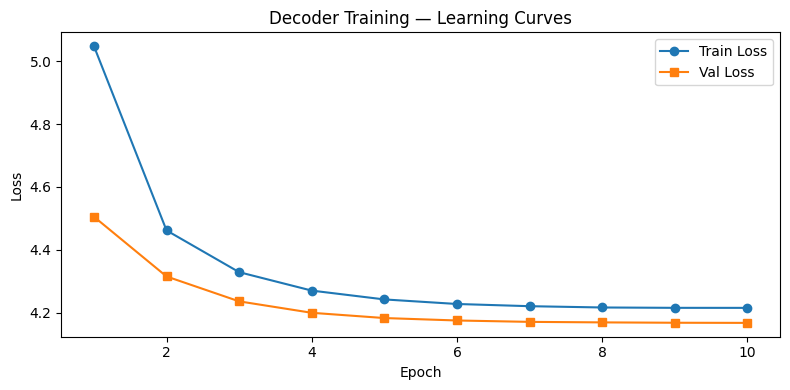

Decoder learning curve saved.


In [36]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, DEC_EPOCHS + 1), decTrainLosses, marker='o', label='Train Loss')
plt.plot(range(1, DEC_EPOCHS + 1), decValLosses,   marker='s', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Decoder Training — Learning Curves')
plt.legend()
plt.tight_layout()
plt.savefig('results/decoderLearning.png')
plt.show()
print('Decoder learning curve saved.')

In [37]:
#perplexity
decoderModel.eval()
totalLoss = 0.0
totalTokens = 0

with torch.no_grad():
    for src, target in testDecLoader:
        src = src.to(DEVICE)
        target = target.to(DEVICE)
        logits = decoderModel(src)
        loss = decCriterion(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))
        #non-padding tokens
        nTokens = (target != PAD_IDX).sum().item()
        totalLoss += loss.item() * nTokens
        totalTokens += nTokens

avgLoss = totalLoss / totalTokens
perplexity = math.exp(avgLoss)
print('Test Set Perplexity: {:.4f}'.format(perplexity))

Test Set Perplexity: 65.0574


In [38]:
# qualitative evaluation
def decodeIds(ids):
    """Convert a list of token ids back to a readable string."""
    tokens = []
    for i in ids:
        w = idx2word.get(i, UNK_TOKEN)
        if w in [PAD_TOKEN, BOS_TOKEN]:
            continue
        if w == EOS_TOKEN:
            break
        tokens.append(w)
    return ' '.join(tokens)


def generateExplanation(rec, includeRetrieval=True, maxNewTokens=30):
    """Build the prompt up to [EXP] <BOS> then generate."""
    def enc(word):
        return word2idx.get(word, UNK_IDX)

    if includeRetrieval:
        qEmb = buildQueryEmbedding(rec['text'])
        topIdxs,_ = retrieveTopK(qEmb, TOP_K)
        ctxTexts = [trainTexts[i] for i in topIdxs]
    else:
        ctxTexts = []

    promptIds = []
    promptIds += [enc('[REVIEW]')] + [enc(t) for t in rec['tokens'][:60]]
    promptIds += [enc('[SENT]'),  enc(SENT_WORDS[rec['sentiment']])]
    promptIds += [enc('[LEN]'),   enc(LEN_WORDS[rec['lengthClass']])]
    if includeRetrieval:
        for ctxText in ctxTexts:
            ctxToks = simpleTokenize(ctxText)[:20]
            promptIds += [enc('[CTX]')] + [enc(t) for t in ctxToks]
    promptIds += [enc('[EXP]'), BOS_IDX]

    promptIds = promptIds[:DEC_MAX_LEN - maxNewTokens]
    promptTensor = torch.tensor([promptIds], dtype=torch.long).to(DEVICE)

    generated = decoderModel.generate(promptTensor, maxNewTokens=maxNewTokens)
    genIds = generated[0, len(promptIds):].tolist()
    return decodeIds(genIds)


print('Generated Explanations')
for qi in range(5):
    rec = testData[qi]
    gen = generateExplanation(rec, includeRetrieval=True)
    ref = rec['explanation']
    print()
    print('Example #{}'.format(qi + 1))
    print('Review   : {:.80s}...'.format(rec['text']))
    print('Sentiment: {}  Length: {}'.format(
        SENT_WORDS[rec['sentiment']], LEN_WORDS[rec['lengthClass']]))
    print('Reference: {}'.format(ref))
    print('Generated: {}'.format(gen))
print()

Generated Explanations

Example #1
Review   : This tool repair kit is useful for repairs on a laptop, smartphone, eyeglasses, ...
Sentiment: positive  Length: short
Reference: this short review indicates positive sentiment about this tool repair
Generated: this short review indicates positive <UNK> about this product

Example #2
Review   : I had to replace the cord from the first one I purchased a month ago, but this o...
Sentiment: positive  Length: short
Reference: this short review indicates positive sentiment about replace
Generated: this short review indicates positive <UNK> about used this

Example #3
Review   : You will have to use more then regular shampoo, because this one is very watery....
Sentiment: negative  Length: short
Reference: this short review indicates negative sentiment about will have
Generated: this short review indicates positive <UNK> about have

Example #4
Review   : Received promptly. As others have noted plastic smoother not included but credit...
Sentiment

In [39]:
#RAG Ablation Study

trainNoRagDataset = DecoderDataset(trainData, isTrain=True,  includeRetrieval=False)
valNoRagDataset = DecoderDataset(valData,   isTrain=False, includeRetrieval=False)
testNoRagDataset = DecoderDataset(testData,  isTrain=False, includeRetrieval=False)

trainNoRagLoader = DataLoader(trainNoRagDataset, batch_size=32, shuffle=True)
valNoRagLoader = DataLoader(valNoRagDataset,   batch_size=32, shuffle=False)
testNoRagLoader = DataLoader(testNoRagDataset,  batch_size=32, shuffle=False)

decoderNoRag = DecoderTransformer(vocabSize=VOCAB_SIZE,dModel=DEC_D_MODEL,nHeads=DEC_N_HEADS,nLayers=DEC_N_LAYERS,dFF=DEC_D_FF,dropout=DEC_DROPOUT).to(DEVICE)

noRagOptimizer = optim.Adam(decoderNoRag.parameters(), lr=DEC_LR)
noRagScheduler = optim.lr_scheduler.StepLR(noRagOptimizer, step_size=1, gamma=0.5)

print('no-RAG baseline decoder')
for epoch in range(DEC_EPOCHS):
    decoderNoRag.train()
    epochLoss = 0.0
    for src, target in trainNoRagLoader:
        src = src.to(DEVICE)
        target = target.to(DEVICE)
        noRagOptimizer.zero_grad()
        logits = decoderNoRag(src)
        loss = decCriterion(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(decoderNoRag.parameters(), max_norm=1.0)
        noRagOptimizer.step()
        epochLoss += loss.item()
    noRagScheduler.step()
    print('  Epoch [{}/{}]  Train Loss: {:.4f}'.format(
        epoch + 1, DEC_EPOCHS, epochLoss / len(trainNoRagLoader)))

no-RAG baseline decoder
  Epoch [1/10]  Train Loss: 4.8476
  Epoch [2/10]  Train Loss: 4.3045
  Epoch [3/10]  Train Loss: 4.1683
  Epoch [4/10]  Train Loss: 4.1042
  Epoch [5/10]  Train Loss: 4.0729
  Epoch [6/10]  Train Loss: 4.0576
  Epoch [7/10]  Train Loss: 4.0504
  Epoch [8/10]  Train Loss: 4.0466
  Epoch [9/10]  Train Loss: 4.0448
  Epoch [10/10]  Train Loss: 4.0438


In [40]:
#perplexity comparison
def computePerplexity(model, dataLoader):
    model.eval()
    totalLoss   = 0.0
    totalTokens = 0
    with torch.no_grad():
        for src, target in dataLoader:
            src = src.to(DEVICE)
            target = target.to(DEVICE)
            logits = model(src)
            loss = decCriterion(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))
            nTokens = (target != PAD_IDX).sum().item()
            totalLoss += loss.item() * nTokens
            totalTokens += nTokens
    return math.exp(totalLoss / totalTokens)


ppxRag = computePerplexity(decoderModel,  testDecLoader)
ppxNoRag = computePerplexity(decoderNoRag,  testNoRagLoader)

print()
print('RAG Ablation Study')

print('Full RAG system  Perplexity: {:.4f}'.format(ppxRag))
print('No-RAG baseline  Perplexity: {:.4f}'.format(ppxNoRag))
improvement = ppxNoRag - ppxRag
print('Improvement (lower is better): {:.4f}'.format(improvement))
if improvement > 0:
    print('RAG retrieval reduces perplexity, demonstrating benefit of context.')
else:
    print('Baseline perplexity is lower. More training epochs may be needed.')


RAG Ablation Study
Full RAG system  Perplexity: 65.0574
No-RAG baseline  Perplexity: 59.0989
Improvement (lower is better): -5.9584
Baseline perplexity is lower. More training epochs may be needed.


In [41]:
torch.save(decoderModel.state_dict(),  'models/decoderRag.pt')
torch.save(decoderNoRag.state_dict(),  'models/decoderNoRag.pt')
print('Decoder weights saved to models/')

Decoder weights saved to models/
